# 🚗 Car Price Prediction using Machine Learning

## 📌 Project Overview

This project predicts the selling price of used cars using Machine Learning.

The workflow includes:

- 📂 Data Loading
- 🧹 Data Cleaning
- 📊 Exploratory Data Analysis (EDA)
- 🔧 Feature Engineering
- 🤖 Model Building
- 📈 Model Evaluation
- 💾 Model Saving

---

### 👨‍💻 Author

**Gaurav Eknath Kumbhar**

MCA Student | Aspiring Data Scientist | Machine Learning Enthusiast


In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("car data.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Values")
print("="*60)

print(df.duplicated().sum())

Dataset Shape
(301, 9)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Missing Values
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


Duplicate Values
2


In [4]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
Year,301.000000,2013.627907,2.891554,2003.000000,2012.000000,2014.000000,2016.000000,2018.000000
Selling_Price,301.000000,4.661296,5.082812,0.100000,0.900000,3.600000,6.000000,35.000000
Present_Price,301.000000,7.628472,8.642584,0.320000,1.200000,6.400000,9.900000,92.600000
Driven_kms,301.000000,36947.205980,38886.883882,500.000000,15000.000000,32000.000000,48767.000000,500000.000000
Owner,301.000000,0.043189,0.247915,0.000000,0.000000,0.000000,0.000000,3.000000


In [5]:
# First 10 Rows
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# ==========================================================
# Data Types
# ==========================================================

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})

dtype_df

,Column,Data Type,Missing Values
0,Car_Name,object,0
1,Year,int64,0
2,Selling_Price,float64,0
3,Present_Price,float64,0
4,Driven_kms,int64,0
5,Fuel_Type,object,0
6,Selling_type,object,0
7,Transmission,object,0
8,Owner,int64,0


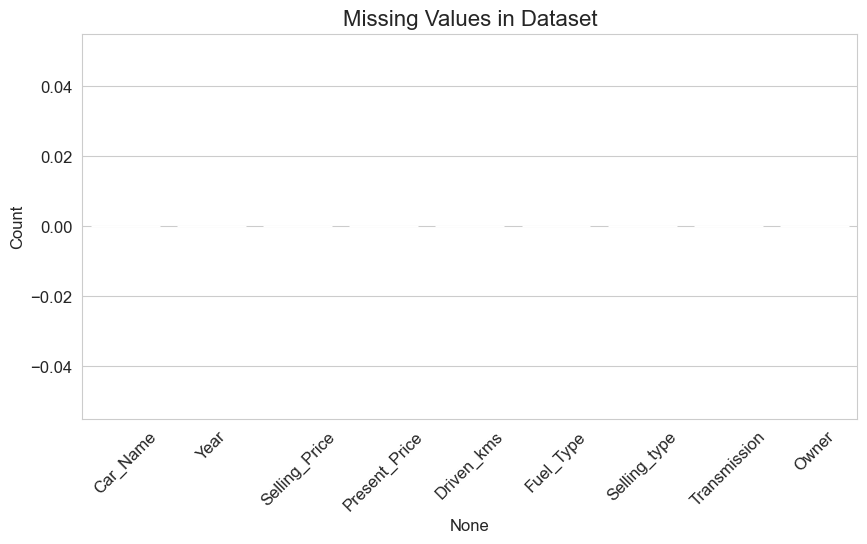

In [7]:
# ==========================================================
# Missing Values Visualization
# ==========================================================

missing = df.isnull().sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing.values,
    palette="viridis"
)

plt.title("Missing Values in Dataset",fontsize=16)

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [8]:
# ==========================================================
# Remove Duplicate Rows
# ==========================================================

print("Before :",df.shape)

df = df.drop_duplicates()

print("After :",df.shape)

Before : (301, 9)
After : (299, 9)


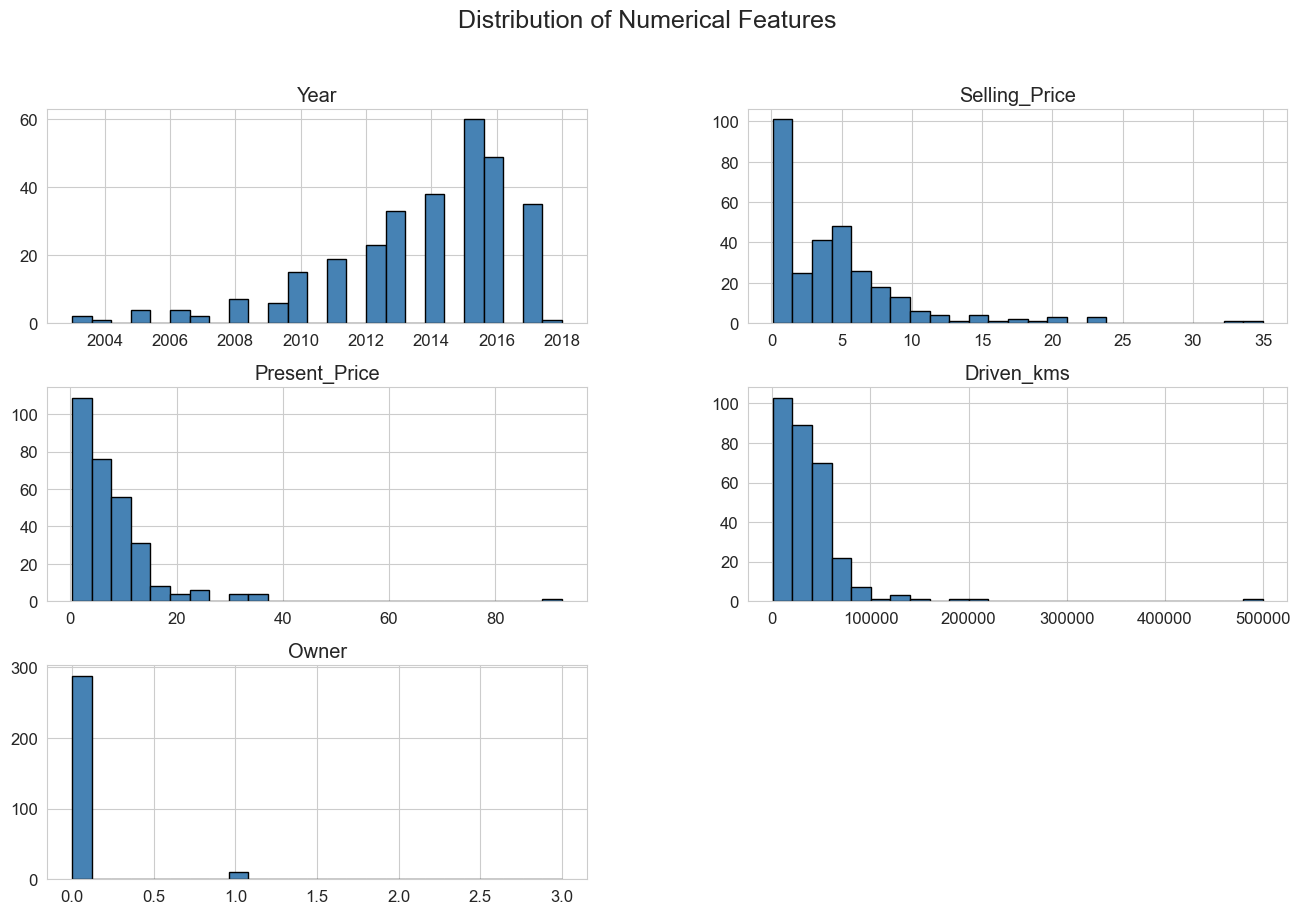

In [9]:
numeric = df.select_dtypes(include=np.number)

numeric.hist(
    figsize=(16,10),
    bins=25,
    color="steelblue",
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features",fontsize=18)

plt.show()

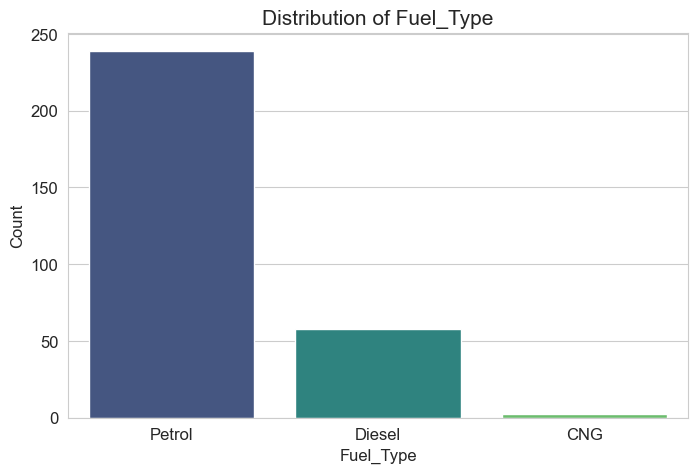

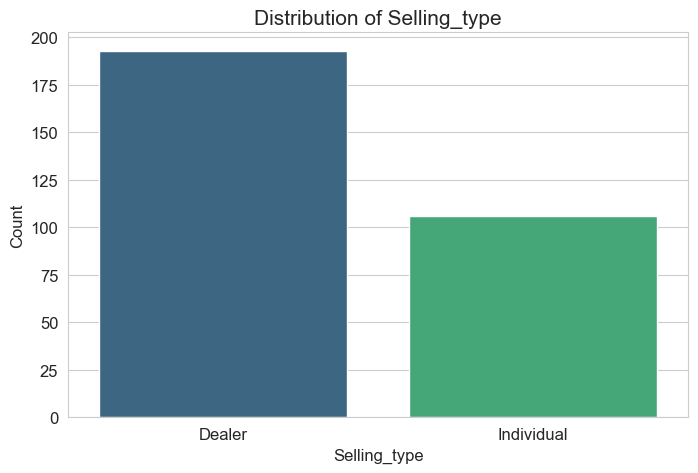

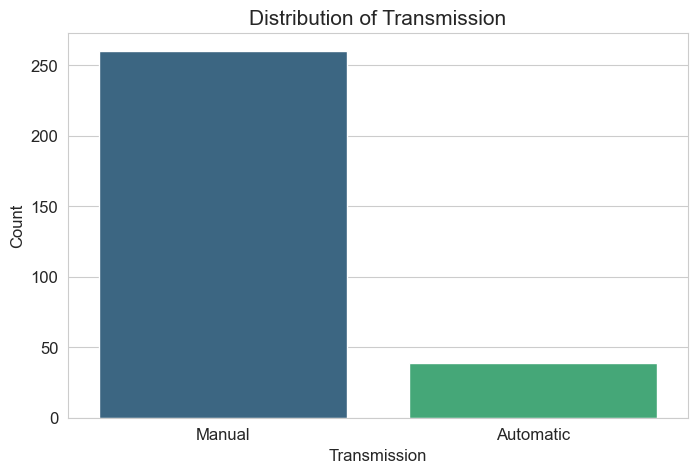

In [10]:
# ==========================================================
# Categorical Features Analysis
# ==========================================================

categorical_columns = ["Fuel_Type", "Selling_type", "Transmission"]

for col in categorical_columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=col,
        palette="viridis"
    )

    plt.title(f"Distribution of {col}", fontsize=15)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

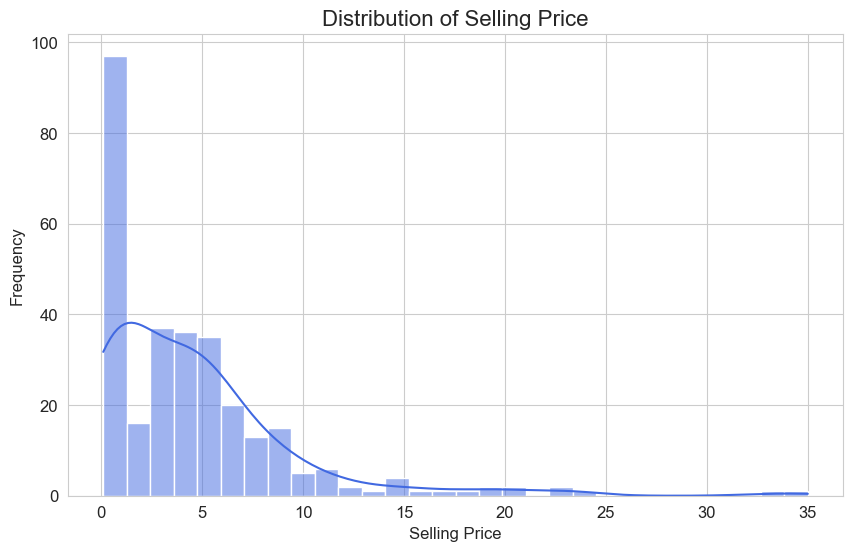

In [11]:
# ==========================================================
# Selling Price Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Selling_Price"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Selling Price", fontsize=16)
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

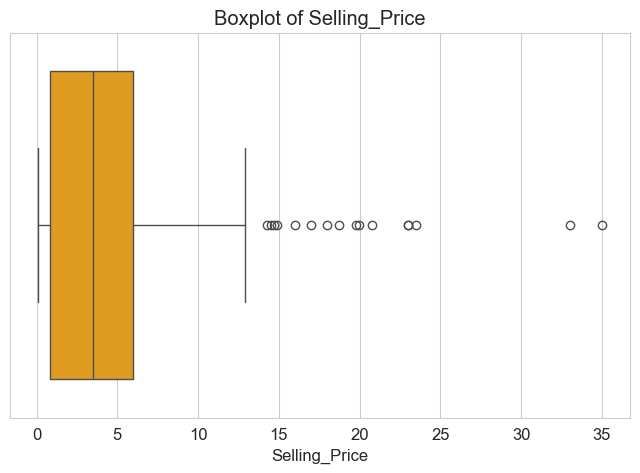

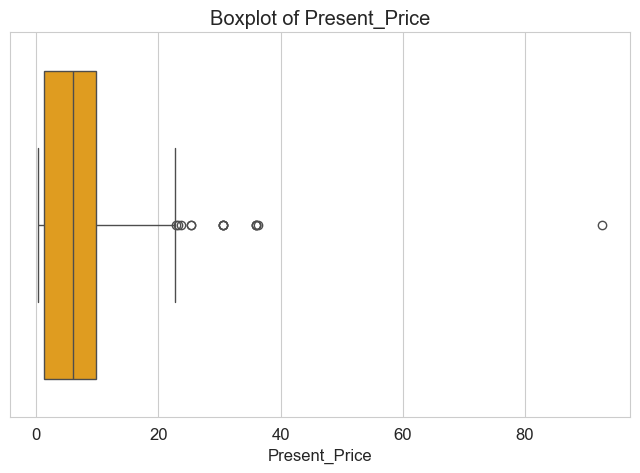

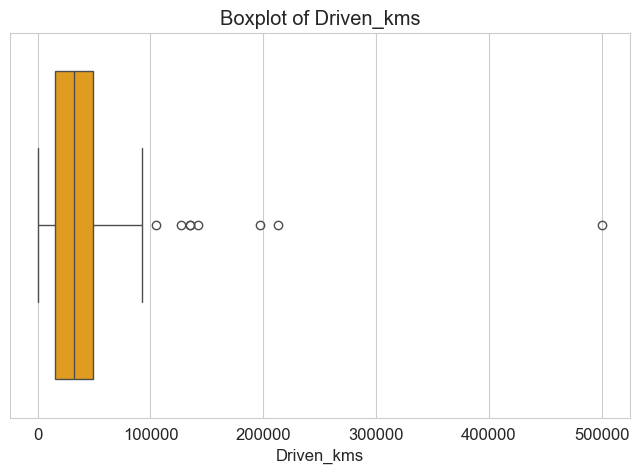

In [12]:
# ==========================================================
# Outlier Detection
# ==========================================================

numerical_columns = [
    "Selling_Price",
    "Present_Price",
    "Driven_kms"
]

for col in numerical_columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df[col],
        color="orange"
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

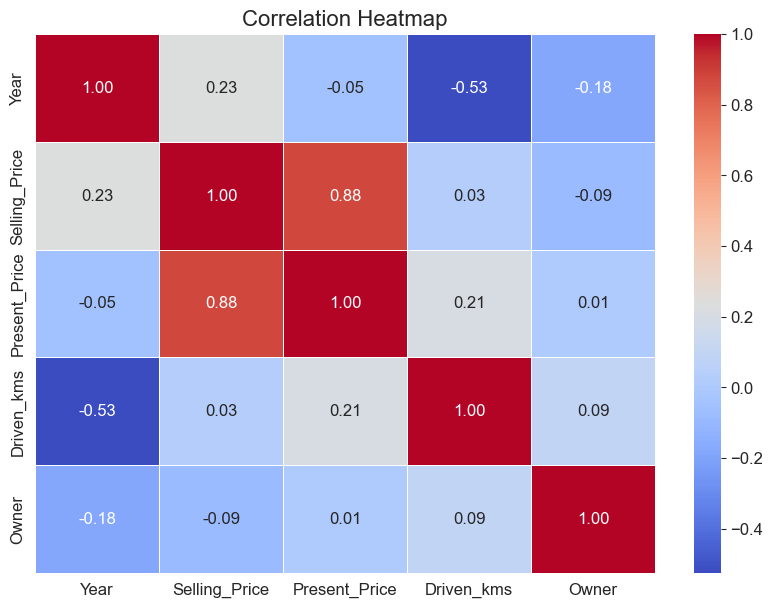

In [13]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,7))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

In [14]:
# ==========================================================
# Feature Engineering
# ==========================================================

CURRENT_YEAR = 2025

df["Car_Age"] = CURRENT_YEAR - df["Year"]

df.drop("Year", axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [15]:
# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,2,0,1,0,11
1,sx4,4.75,9.54,43000,1,0,1,0,12
2,ciaz,7.25,9.85,6900,2,0,1,0,8
3,wagon r,2.85,4.15,5200,2,0,1,0,14
4,swift,4.60,6.87,42450,1,0,1,0,11


In [16]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (299, 8)
Target Shape : (299,)


In [17]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (239, 8)
Testing Samples : (60, 8)


In [18]:
print(X_train.dtypes)

Car_Name          object
Present_Price    float64
Driven_kms         int64
Fuel_Type          int64
Selling_type       int64
Transmission       int64
Owner              int64
Car_Age            int64
dtype: object


In [19]:
print(X_train.select_dtypes(include="object").columns)

Index(['Car_Name'], dtype='object')


In [20]:
print(X.columns.tolist())

['Car_Name', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [21]:
X = df.drop(columns=["Selling_Price", "Car_Name"])
y = df["Selling_Price"]

In [22]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (239, 7)
Testing Samples : (60, 7)


In [23]:
# ==========================================================
# Model Training
# ==========================================================

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    results[name] = score

    print(f"{name} R² Score : {score:.4f}")

Linear Regression R² Score : 0.7410
Decision Tree R² Score : 0.8252
Random Forest R² Score : 0.5207


In [24]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model": results.keys(),

    "R² Score": results.values()

})

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

comparison

,Model,R² Score
1,Decision Tree,0.825168
0,Linear Regression,0.740993
2,Random Forest,0.520729


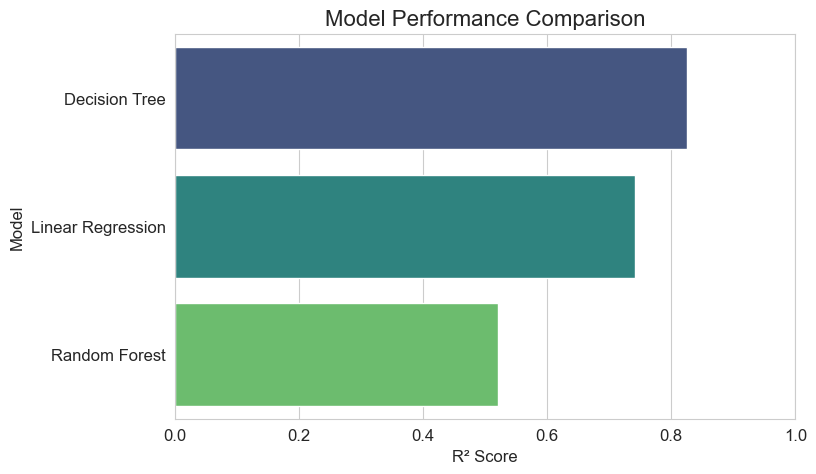

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="R² Score",
    y="Model",
    palette="viridis"
)

plt.title("Model Performance Comparison", fontsize=16)

plt.xlim(0, 1)

plt.show()

In [26]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [27]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = best_model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [28]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 1.465
MSE  : 11.955
RMSE : 3.458
R²   : 0.536


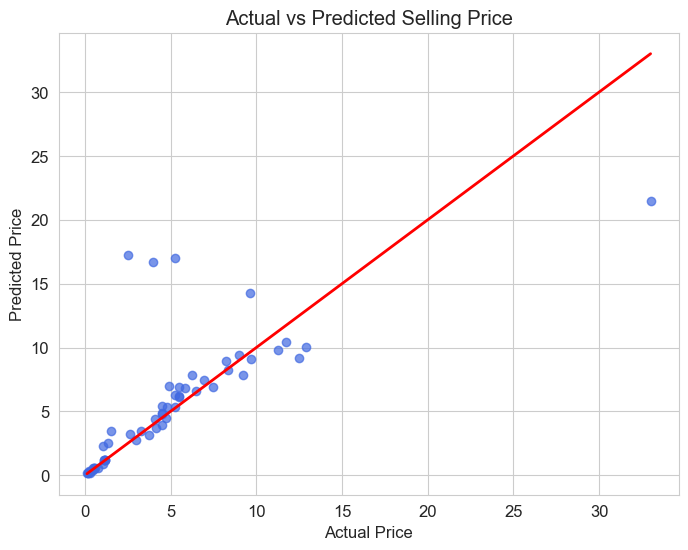

In [29]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color="royalblue",
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Selling Price")

plt.grid(True)

plt.show()

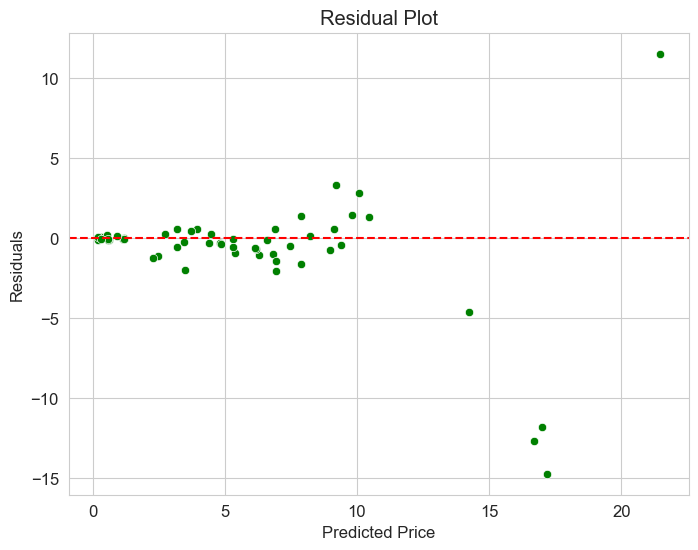

In [30]:
# ==========================================================
# Residual Analysis
# ==========================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    color="green"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [31]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,0.905729
6,Car_Age,0.069732
1,Driven_kms,0.014841
4,Transmission,0.005437
3,Selling_type,0.002670
2,Fuel_Type,0.001582
5,Owner,0.000010


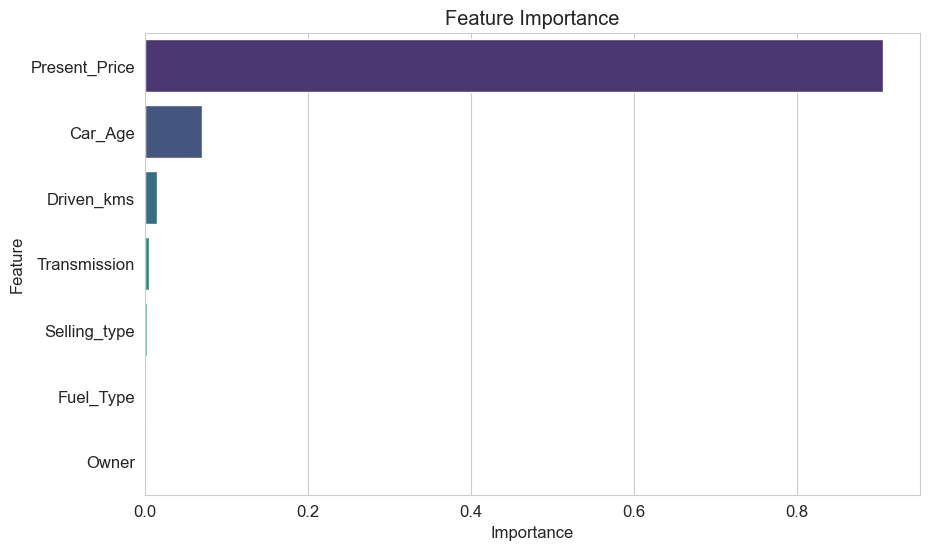

In [32]:
# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

In [33]:
# ==========================================================
# Save Model
# ==========================================================

joblib.dump(best_model, "car_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
# ==========================================================
# Sample Prediction
# ==========================================================

sample = X.iloc[[0]]

prediction = best_model.predict(sample)

print("Predicted Selling Price : ₹", round(prediction[0],2),"Lakhs")

Predicted Selling Price : ₹ 3.64 Lakhs


In [35]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print()

print("Model Used : Random Forest Regressor")

print()

print(f"Final R² Score : {r2:.3f}")

print()

print("The model is now ready for deployment using Streamlit.")

PROJECT COMPLETED SUCCESSFULLY

Model Used : Random Forest Regressor

Final R² Score : 0.536

The model is now ready for deployment using Streamlit.


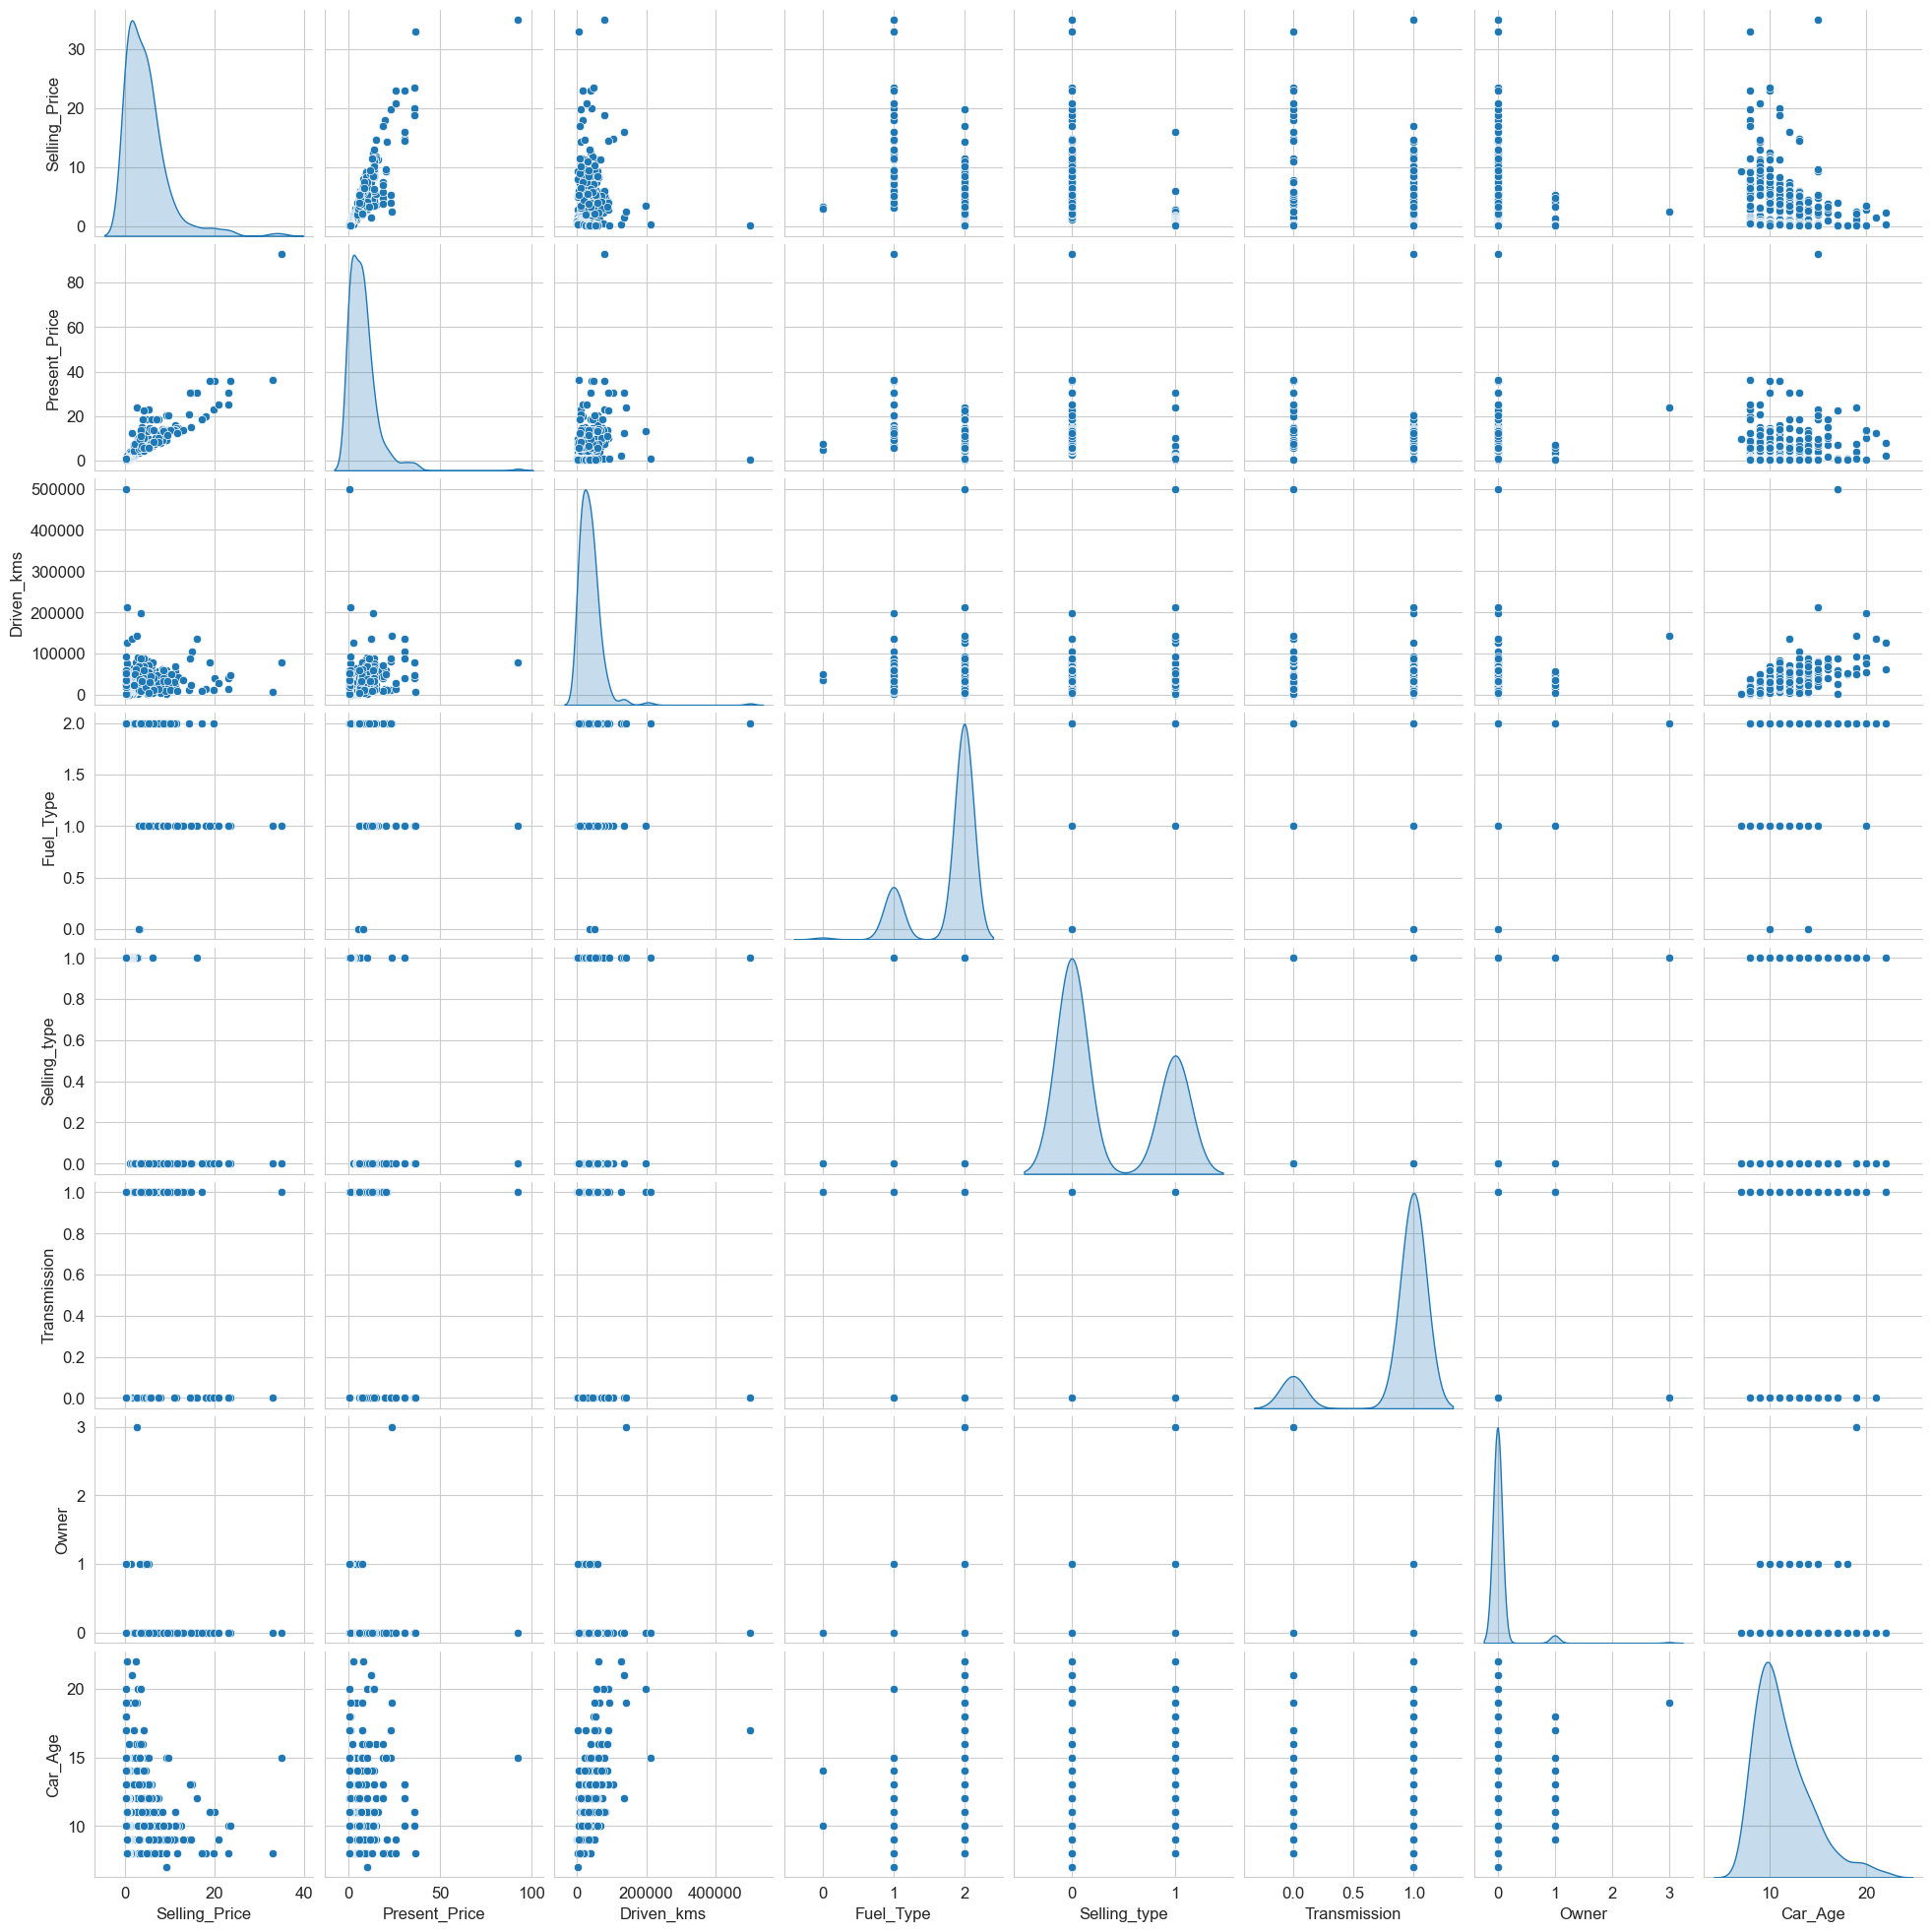

In [36]:
sns.pairplot(
    df.select_dtypes(include=np.number),
    diag_kind="kde"
)
plt.show()

In [37]:
df.corr(numeric_only=True).style.background_gradient(cmap="coolwarm")

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
Selling_Price,1.000000,0.876305,0.028566,-0.500292,-0.553851,-0.348869,-0.087880,-0.234369
Present_Price,0.876305,1.000000,0.205224,-0.431887,-0.511779,-0.334326,0.009948,0.053167
Driven_kms,0.028566,0.205224,1.000000,-0.167287,-0.101030,-0.163881,0.089367,0.525714
Fuel_Type,-0.500292,-0.431887,-0.167287,1.000000,0.347922,0.068618,0.054174,0.046210
Selling_type,-0.553851,-0.511779,-0.101030,0.347922,1.000000,0.058669,0.123646,0.036820
Transmission,-0.348869,-0.334326,-0.163881,0.068618,0.058669,1.000000,-0.052166,-0.003434
Owner,-0.087880,0.009948,0.089367,0.054174,0.123646,-0.052166,1.000000,0.181639
Car_Age,-0.234369,0.053167,0.525714,0.046210,0.036820,-0.003434,0.181639,1.000000


In [38]:
df.to_csv("cleaned_car_data.csv", index=False)

In [39]:
importance.to_csv("feature_importance.csv", index=False)

"""# 🎉 Thank You!

## Project Completed Successfully

#**Author:** Gaurav Eknath Kumbhar#

### Skills Demonstrated
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning
- Hyperparameter Tuning
- Model Evaluation
- Model Persistence

0#⭐ Thank you for exploring this project!#"""

In [40]:
print(X.columns.tolist())

['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [41]:
X.columns

Index(['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
       'Transmission', 'Owner', 'Car_Age'],
      dtype='object')

In [42]:
print(df["Fuel_Type"].unique())
print(df["Selling_type"].unique())
print(df["Transmission"].unique())

[2 1 0]
[0 1]
[1 0]


In [43]:
plot_df = df.copy()

plot_df["Fuel_Type"] = plot_df["Fuel_Type"].replace({
    0: "CNG",
    1: "Diesel",
    2: "Petrol"
})

plot_df["Selling_type"] = plot_df["Selling_type"].replace({
    0: "Dealer",
    1: "Individual"
})

plot_df["Transmission"] = plot_df["Transmission"].replace({
    0: "Automatic",
    1: "Manual"
})

In [44]:
df

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,2,0,1,0,11
1,sx4,4.75,9.54,43000,1,0,1,0,12
2,ciaz,7.25,9.85,6900,2,0,1,0,8
3,wagon r,2.85,4.15,5200,2,0,1,0,14
4,swift,4.60,6.87,42450,1,0,1,0,11
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,1,0,1,0,9
297,brio,4.00,5.90,60000,2,0,1,0,10
298,city,3.35,11.00,87934,2,0,1,0,16
299,city,11.50,12.50,9000,1,0,1,0,8


In [45]:
plot_df

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,11
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,9
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,10
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,16
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,8


In [46]:
print(df.columns)

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


In [47]:
print(df["Fuel_Type"].head())

0    2
1    1
2    2
3    2
4    1
Name: Fuel_Type, dtype: int64
